In [1]:
# libaries ko import karein
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import os

print("Libraries successfully import ho gayi hain.")

Libraries successfully import ho gayi hain.


In [2]:
# dataset load karein
df = pd.read_csv("emails.csv")
print("Dataset load ho gaya hai.")
print(df.head())

Dataset load ho gaya hai.
  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0               0         0         0   0    0           0  
4       0    0               0         0         0   1    0           0  

[5 rows x 3002 columns]


In [3]:
# dataset ko check karein
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), object(1)
memory usage: 118.5+ MB
None
               the           to          ect          and          for  \
count  5172.000000  5172.000000  5172.000000  5172.000000  5172.000000   
mean      6.640565     6.188128     5.143852     3.075599     3.124710   
std      11.745009     9.534576    14.101142     6.045970     4.680522   
min       0.000000     0.000000     1.000000     0.000000     0.000000   
25%       0.000000     1.000000     1.000000     0.000000     1.000000   
50%       3.000000     3.000000     1.000000     1.000000     2.000000   
75%       8.000000     7.000000     4.000000     3.000000     4.000000   
max     210.000000   132.000000   344.000000    89.000000    47.000000   

                of            a          you          hou           in  ...  \
count  5172.000000  5172.000000  5172.000000  5172.000000  5172.000000  .

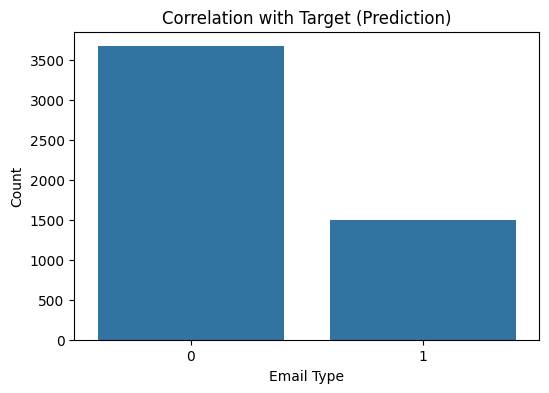

In [4]:
# prediction distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Prediction', data=df)
plt.title("Correlation with Target (Prediction)")
plt.xlabel("Email Type")
plt.ylabel("Count")
plt.show()

In [5]:
# dataset ko split karein
x = df.drop(['Prediction', 'Email No.'], axis=1)
y = df['Prediction']

# training data 80%, test data 20%
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print('Successfully split ho gaya hai.')
print(f"Features shape: {x_train.shape}")

Successfully split ho gaya hai.
Features shape: (4137, 3000)


In [6]:
# 1. ultinomial naive bayes model ka instance banayein
model = MultinomialNB()

# model ko training data dikha kar 'fit' (train) karein
model.fit(x_train, y_train)
print("Model successfully train ho gaya hai.")

Model successfully train ho gaya hai.


Model ki accuracy: 95.46%

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       739
           1       0.89      0.96      0.92       296

    accuracy                           0.95      1035
   macro avg       0.94      0.96      0.95      1035
weighted avg       0.96      0.95      0.96      1035



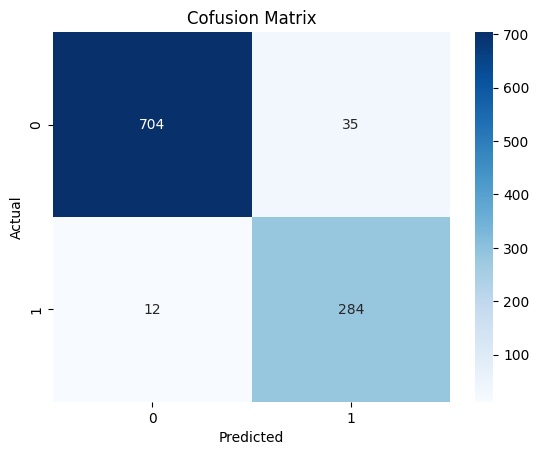

In [7]:
# test data pr prediction karein
y_pred = model.predict(x_test)

# accuracy check karein
accuracy = accuracy_score(y_test, y_pred)
print(f"Model ki accuracy: {accuracy * 100:.2f}%")

# detail report dekhain
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Cofusion Matrix')
plt.show()

In [8]:
# model ko save karein
import pickle
with open('spam_model.pkl', 'wb') as file:
    pickle.dump(model, file)
print("Model 'spam_model.pkl' ke naam se save ho gaya hai.")

Model 'spam_model.pkl' ke naam se save ho gaya hai.


In [9]:
# 'email no. aur prediction nikal kar baaki words ki list lein
words_list = x.columns.tolist()
with open('words_list.pkl', 'wb') as f:
    pickle.dump(words_list, f)
print("Words list save ho gayi hai!")

Words list save ho gayi hai!
